# Does Visual-Language Context Improve Action Recognition?
## Evaluating Qwen2-VL 7B on Kinetics-400 Mini

**Replication of UCF-101 experiment on a modern benchmark.**

**Three conditions:**
- **Condition A** — Video frame only (zero-shot baseline)
- **Condition B** — Video frame + ground truth label (oracle upper bound)
- **Condition C** — Video frame + wrong label (noise injection control)

**Research question:** Does the finding from UCF-101 replicate on Kinetics-400 — a harder, more modern benchmark?

**Dataset:** Kinetics-400 Mini — 200 action classes, ~18 videos per class, YouTube clips (.mp4)  
**Model:** Qwen2-VL 7B  
**Hardware:** T4 16GB GPU (Kaggle free tier)

## 1. Setup

In [1]:
import subprocess, sys
def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

install('transformers>=4.37.0')
install('accelerate')
install('qwen-vl-utils')
install('opencv-python-headless')
for pkg in ['Pillow', 'pandas', 'numpy', 'matplotlib', 'scipy', 'tqdm']:
    install(pkg)
print('Done')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 MB 50.6 MB/s eta 0:00:00
Done


In [2]:
import os, random
import numpy as np
import pandas as pd
import torch
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from pathlib import Path
from scipy.stats import chi2
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU : {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

Device: cuda
GPU : Tesla T4
VRAM: 15.6 GB


## 2. Kinetics-400 Mini Dataset
Ground truth label = folder name (may contain spaces). No annotation file needed.

In [3]:
K400_ROOT = Path('/kaggle/input/datasets/duckdai/kinetics400-mini/kinetics400_mini/train')

# Class names from folder names — may contain spaces e.g. 'drinking beer'
ALL_CLASSES = sorted([d.name for d in K400_ROOT.iterdir() if d.is_dir()])
print(f'Total action classes: {len(ALL_CLASSES)}')
print('Sample classes:', ALL_CLASSES[:10])

Total action classes: 200
Sample classes: ['abseiling', 'air drumming', 'answering questions', 'applauding', 'applying cream', 'archery', 'arm wrestling', 'arranging flowers', 'assembling computer', 'auctioning']


In [4]:
def extract_middle_frame(video_path):
    """
    Extract the middle frame from a video as a PIL Image.
    Middle frame avoids intro/outro and captures peak action.
    """
    cap = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total == 0:
        cap.release()
        return None
    cap.set(cv2.CAP_PROP_POS_FRAMES, total // 2)
    ret, frame = cap.read()
    cap.release()
    if not ret:
        return None
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    return Image.fromarray(frame_rgb)


def build_sample_list(root, n_per_class=2, seed=42):
    """
    Build a balanced sample list: n_per_class videos per action class.
    Returns list of (video_path, label) tuples.
    Handles .mp4 files and class names with spaces.
    """
    random.seed(seed)
    samples = []
    for class_dir in sorted(root.iterdir()):
        if not class_dir.is_dir():
            continue
        videos = list(class_dir.glob('*.mp4'))
        if not videos:
            continue
        selected = random.sample(videos, min(n_per_class, len(videos)))
        for v in selected:
            samples.append((v, class_dir.name))
    random.shuffle(samples)
    return samples


def get_wrong_label(correct_label, all_classes):
    pool = [c for c in all_classes if c != correct_label]
    return random.choice(pool)


# N_PER_CLASS=2 gives ~400 samples (2 per class x 200 classes)
N_PER_CLASS = 2
samples = build_sample_list(K400_ROOT, n_per_class=N_PER_CLASS)
print(f'Total samples: {len(samples)}')
print('Example:', samples[0])

Total samples: 400
Example: (PosixPath('/kaggle/input/datasets/duckdai/kinetics400-mini/kinetics400_mini/train/bobsledding/TDQ3c39we9s.mp4'), 'bobsledding')


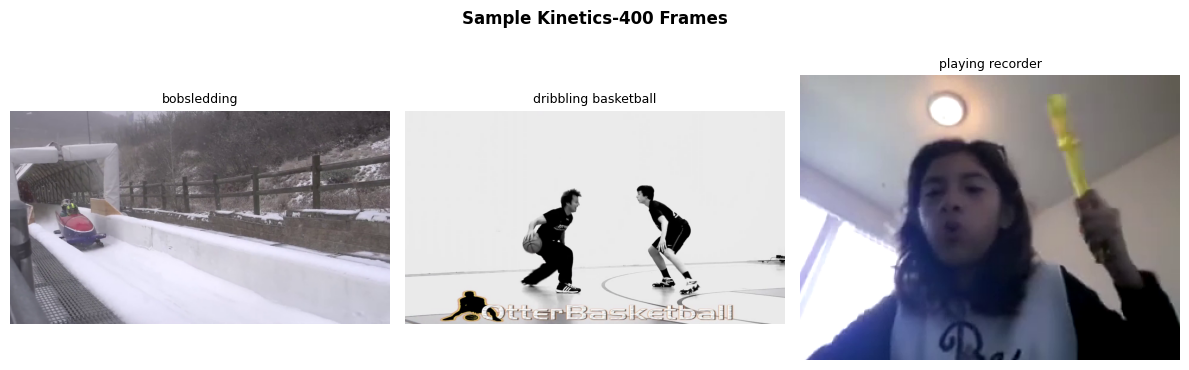

In [5]:
# Sanity check — show 3 sample frames
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, ax in enumerate(axes):
    video_path, label = samples[i]
    frame = extract_middle_frame(video_path)
    if frame:
        ax.imshow(frame)
        ax.set_title(label, fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Kinetics-400 Frames', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/sample_frames.png', dpi=100)
plt.show()

## 3. Qwen2-VL 7B — Three Condition Inference

In [6]:
class Qwen2VLEvaluator:
    """
    Qwen2-VL 7B inference across three evaluation conditions.

    A: zero-shot   — raw visual understanding, no context
    B: oracle      — ground truth label as context (upper bound)
    C: noise       — wrong label as context (proves genuine context use)
    """
    def __init__(self, model_name='Qwen/Qwen2-VL-7B-Instruct'):
        print(f'Loading {model_name}...')
        self.processor = AutoProcessor.from_pretrained(
            model_name,
            min_pixels=256*28*28,
            max_pixels=1280*28*28
        )
        self.model = Qwen2VLForConditionalGeneration.from_pretrained(
            model_name,
            torch_dtype=torch.float16,
            device_map='auto'
        )
        self.model.eval()
        print('Qwen2-VL 7B ready')

    def _prompt(self, condition, gt_label=None, wrong_label=None):
        class_list = ', '.join(ALL_CLASSES)

        if condition == 'A':
            return (
                f'You are an action recognition system. '
                f'Possible action classes: {class_list}. '
                f'What action is being performed in this image? '
                f'Return only the single class name from the list above. No explanation.'
            )
        elif condition == 'B':
            return (
                f'A reference system identified the action as: {gt_label}. '
                f'Using this context and the image, select the correct action from: {class_list}. '
                f'Return only the single class name. No explanation.'
            )
        elif condition == 'C':
            return (
                f'A reference system identified the action as: {wrong_label}. '
                f'Using this context and the image, select the correct action from: {class_list}. '
                f'Return only the single class name. No explanation.'
            )

    def predict(self, image, condition, gt_label=None, wrong_label=None):
        prompt = self._prompt(condition, gt_label, wrong_label)
        messages = [{'role': 'user', 'content': [
            {'type': 'image', 'image': image},
            {'type': 'text', 'text': prompt}
        ]}]
        text = self.processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        inputs = self.processor(
            text=[text], images=[image], return_tensors='pt'
        ).to(self.model.device)

        with torch.no_grad():
            out = self.model.generate(
                **inputs, max_new_tokens=50, do_sample=False
            )
        generated = self.processor.batch_decode(
            out[:, inputs.input_ids.shape[1]:],
            skip_special_tokens=True
        )[0].strip()
        return generated


model = Qwen2VLEvaluator()

Loading Qwen/Qwen2-VL-7B-Instruct...


preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/244 [00:00<?, ?B/s]

Qwen2-VL 7B ready


## 4. Evaluation Framework

In [7]:
class ResultsTracker:
    """
    Tracks predictions and computes accuracy across all three conditions.
    Kinetics-400 class names have spaces — hit uses case-insensitive substring match.
    """
    def __init__(self):
        self.records = []
        self.hits = {'A': [], 'B': [], 'C': []}

    def _hit(self, predicted, ground_truth):
        pred = predicted.strip().lower()
        gt = ground_truth.strip().lower()
        return int(gt in pred or pred in gt or pred == gt)

    def add(self, video_path, gt_label, pred_A, pred_B, pred_C, wrong_label):
        hit_A = self._hit(pred_A, gt_label)
        hit_B = self._hit(pred_B, gt_label)
        hit_C = self._hit(pred_C, gt_label)
        self.hits['A'].append(hit_A)
        self.hits['B'].append(hit_B)
        self.hits['C'].append(hit_C)
        self.records.append({
            'video': str(video_path.name),
            'ground_truth': gt_label,
            'pred_A': pred_A, 'pred_B': pred_B, 'pred_C': pred_C,
            'wrong_label': wrong_label,
            'hit_A': hit_A, 'hit_B': hit_B, 'hit_C': hit_C
        })

    def accuracy(self, cond):
        return np.mean(self.hits[cond]) if self.hits[cond] else 0.0

    def to_dataframe(self):
        return pd.DataFrame(self.records)

    def summary(self):
        n = len(self.records)
        a, b, c = self.accuracy('A'), self.accuracy('B'), self.accuracy('C')
        print('\n' + '='*55)
        print('RESULTS — Qwen2-VL 7B on Kinetics-400 Mini')
        print('='*55)
        print(f'Samples evaluated    : {n}')
        print(f'A  Zero-shot         : {a:.3f}')
        print(f'B  Oracle grounded   : {b:.3f}  ({b-a:+.3f} vs A)')
        print(f'C  Noise injection   : {c:.3f}  ({c-a:+.3f} vs A)')
        print('='*55)


tracker = ResultsTracker()
print('Tracker ready')

Tracker ready


## 5. Run Evaluation

In [8]:
skipped = 0

for idx, (video_path, gt_label) in enumerate(tqdm(samples, desc='Evaluating')):

    frame = extract_middle_frame(video_path)
    if frame is None:
        skipped += 1
        continue

    wrong_label = get_wrong_label(gt_label, ALL_CLASSES)

    pred_A = model.predict(frame, 'A')
    pred_B = model.predict(frame, 'B', gt_label=gt_label)
    pred_C = model.predict(frame, 'C', wrong_label=wrong_label)

    tracker.add(video_path, gt_label, pred_A, pred_B, pred_C, wrong_label)

    if (idx + 1) % 25 == 0:
        tracker.to_dataframe().to_csv('/kaggle/working/checkpoint.csv', index=False)
        print(f'[{idx+1}/{len(samples)}] A={tracker.accuracy("A"):.3f} B={tracker.accuracy("B"):.3f} C={tracker.accuracy("C"):.3f}')

results_df = tracker.to_dataframe()
results_df.to_csv('/kaggle/working/final_results_k400.csv', index=False)
print(f'\nDone. Skipped {skipped} unreadable videos.')
tracker.summary()

Evaluating:   6%|▋         | 25/400 [02:39<31:47,  5.09s/it] 

[25/400] A=0.560 B=1.000 C=0.520


Evaluating:  12%|█▎        | 50/400 [05:53<1:00:33, 10.38s/it]

[50/400] A=0.640 B=0.980 C=0.560


Evaluating:  19%|█▉        | 75/400 [09:23<38:24,  7.09s/it]  

...

[350/400] A=0.649 B=0.991 C=0.494


Evaluating:  94%|█████████▍| 375/400 [49:04<03:32,  8.51s/it]

[375/400] A=0.643 B=0.992 C=0.488


Evaluating: 100%|██████████| 400/400 [52:01<00:00,  7.80s/it]

[400/400] A=0.642 B=0.993 C=0.487

Done. Skipped 0 unreadable videos.

RESULTS — Qwen2-VL 7B on Kinetics-400 Mini
Samples evaluated    : 400
A  Zero-shot         : 0.642
B  Oracle grounded   : 0.993  (+0.350 vs A)
C  Noise injection   : 0.487  (-0.155 vs A)


## 6. Statistical Significance — McNemar Test

In [9]:
def mcnemar_test(hits_A, hits_B, label=''):
    n01 = sum(1 for a, b in zip(hits_A, hits_B) if a == 0 and b == 1)
    n10 = sum(1 for a, b in zip(hits_A, hits_B) if a == 1 and b == 0)
    if n01 + n10 == 0:
        print(f'{label}: No discordant pairs — identical performance'); return
    chi2_stat = (abs(n01 - n10) - 1) ** 2 / (n01 + n10)
    p = 1 - chi2.cdf(chi2_stat, df=1)
    direction = 'B better' if n01 > n10 else 'A better'
    print(f'{label}')
    print(f'  B correct/A wrong: {n01}  |  A correct/B wrong: {n10}  |  {direction}')
    print(f'  chi2={chi2_stat:.3f}  p={p:.4f}  significant (p<0.05): {p < 0.05}\n')

print('Statistical Significance')
print('='*55)
mcnemar_test(tracker.hits['A'], tracker.hits['B'], 'Oracle grounded (B) vs Zero-shot (A)')
mcnemar_test(tracker.hits['A'], tracker.hits['C'], 'Noise injection (C) vs Zero-shot (A)')
mcnemar_test(tracker.hits['B'], tracker.hits['C'], 'Oracle grounded (B) vs Noise (C)')

Statistical Significance
Oracle grounded (B) vs Zero-shot (A)
  B correct/A wrong: 140  |  A correct/B wrong: 0  |  B better
  chi2=138.007  p=0.0000  significant (p<0.05): True

Noise injection (C) vs Zero-shot (A)
  B correct/A wrong: 8  |  A correct/B wrong: 70  |  A better
  chi2=47.705  p=0.0000  significant (p<0.05): True

Oracle grounded (B) vs Noise (C)
  B correct/A wrong: 0  |  A correct/B wrong: 202  |  A better
  chi2=200.005  p=0.0000  significant (p<0.05): True



## 7. Visualisation

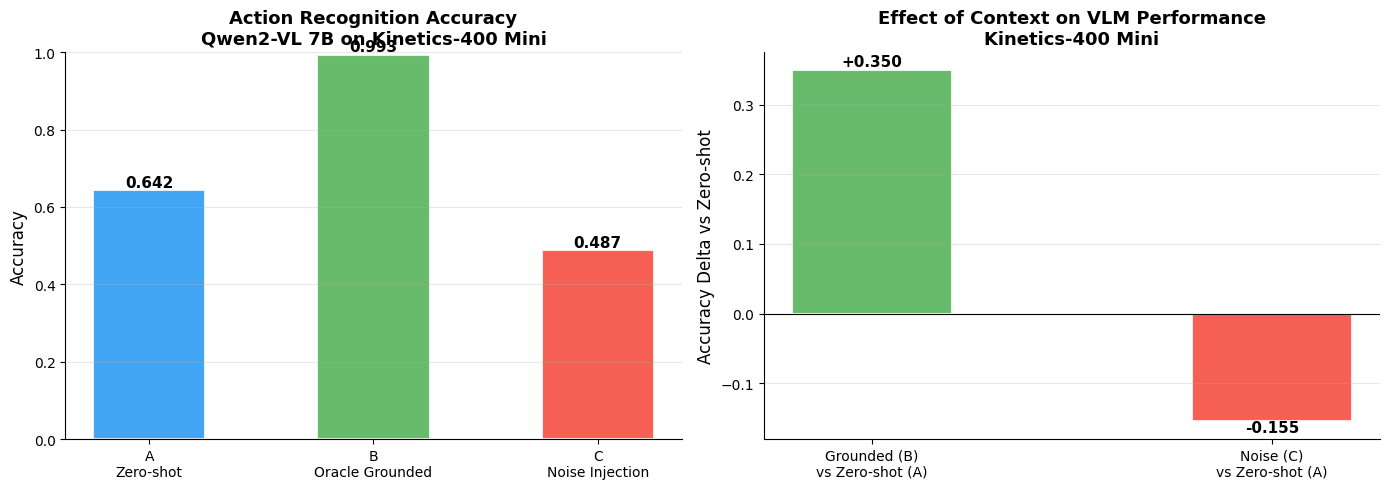

In [10]:
acc_A = tracker.accuracy('A')
acc_B = tracker.accuracy('B')
acc_C = tracker.accuracy('C')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

conds = ['A\nZero-shot', 'B\nOracle Grounded', 'C\nNoise Injection']
accs = [acc_A, acc_B, acc_C]
cols = ['#2196F3', '#4CAF50', '#F44336']
bars = axes[0].bar(conds, accs, color=cols, alpha=0.85, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Action Recognition Accuracy\nQwen2-VL 7B on Kinetics-400 Mini', fontsize=13, fontweight='bold')
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{acc:.3f}', ha='center', fontweight='bold', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

deltas = [acc_B - acc_A, acc_C - acc_A]
dlabels = ['Grounded (B)\nvs Zero-shot (A)', 'Noise (C)\nvs Zero-shot (A)']
dcols = ['#4CAF50' if d >= 0 else '#F44336' for d in deltas]
bars2 = axes[1].bar(dlabels, deltas, color=dcols, alpha=0.85, edgecolor='white', linewidth=1.5, width=0.4)
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].set_ylabel('Accuracy Delta vs Zero-shot', fontsize=12)
axes[1].set_title('Effect of Context on VLM Performance\nKinetics-400 Mini', fontsize=13, fontweight='bold')
for bar, d in zip(bars2, deltas):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.005 if d >= 0 else -0.015),
                f'{d:+.3f}', ha='center', fontweight='bold', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/kaggle/working/results_k400.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Cross-Dataset Comparison — UCF-101 vs Kinetics-400

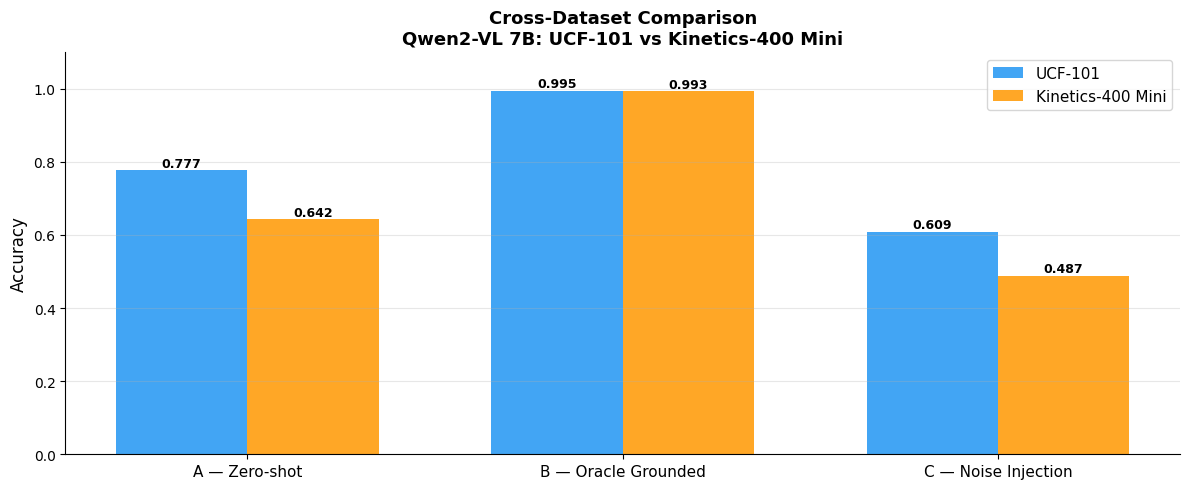


Cross-dataset summary:
                               UCF-101   K400-Mini
A  Zero-shot                   0.777     0.642
B  Oracle grounded             0.995     0.993
C  Noise injection             0.609     0.487
Delta B-A                      +0.218    +0.350
Delta C-A                      -0.168    -0.155


In [11]:
# UCF-101 results from previous experiment — paste your values here
UCF_A = 0.777
UCF_B = 0.995
UCF_C = 0.609

K400_A = acc_A
K400_B = acc_B
K400_C = acc_C

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(3)
width = 0.35
cond_labels = ['A — Zero-shot', 'B — Oracle Grounded', 'C — Noise Injection']
ucf_vals = [UCF_A, UCF_B, UCF_C]
k400_vals = [K400_A, K400_B, K400_C]

bars1 = ax.bar(x - width/2, ucf_vals, width, label='UCF-101', color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + width/2, k400_vals, width, label='Kinetics-400 Mini', color='#FF9800', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(cond_labels, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Cross-Dataset Comparison\nQwen2-VL 7B: UCF-101 vs Kinetics-400 Mini', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
           f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
           f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/cross_dataset_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCross-dataset summary:')
print(f'{"":30} UCF-101   K400-Mini')
print(f'{"A  Zero-shot":30} {UCF_A:.3f}     {K400_A:.3f}')
print(f'{"B  Oracle grounded":30} {UCF_B:.3f}     {K400_B:.3f}')
print(f'{"C  Noise injection":30} {UCF_C:.3f}     {K400_C:.3f}')
print(f'{"Delta B-A":30} {UCF_B-UCF_A:+.3f}    {K400_B-K400_A:+.3f}')
print(f'{"Delta C-A":30} {UCF_C-UCF_A:+.3f}    {K400_C-K400_A:+.3f}')

## 9. Per-Class Analysis

In [12]:
per_class = results_df.groupby('ground_truth').agg(
    acc_A=('hit_A', 'mean'),
    acc_B=('hit_B', 'mean'),
    acc_C=('hit_C', 'mean'),
    n=('hit_A', 'count')
).reset_index()
per_class['delta_B_A'] = per_class['acc_B'] - per_class['acc_A']
per_class = per_class.sort_values('delta_B_A', ascending=False)

print('Classes with biggest improvement from grounding (B vs A):')
print(per_class.head(10).to_string(index=False))
print()
print('Classes already strong zero-shot (small delta):')
print(per_class.tail(10).to_string(index=False))

per_class.to_csv('/kaggle/working/per_class_k400.csv', index=False)

Classes with biggest improvement from grounding (B vs A):
                 ground_truth  acc_A  acc_B  acc_C  n  delta_B_A
                   applauding    0.0    1.0    0.0  2        1.0
                 cartwheeling    0.0    1.0    0.0  2        1.0
                  bookbinding    0.0    1.0    0.0  2        1.0
                brushing hair    0.0    1.0    0.0  2        1.0
               blowing leaves    0.0    1.0    0.5  2        1.0
                 blowing nose    0.0    1.0    0.0  2        1.0
                   beatboxing    0.0    1.0    0.0  2        1.0
                bending metal    0.0    1.0    0.0  2        1.0
                  celebrating    0.0    1.0    0.0  2        1.0
catching or throwing softball    0.0    1.0    0.0  2        1.0

Classes already strong zero-shot (small delta):
                 ground_truth  acc_A  acc_B  acc_C  n  delta_B_A
                playing cards    1.0    1.0    1.0  2        0.0
                playing chess    1.0    1.0    0

## 10. Key Findings

In [13]:
print('KEY FINDINGS — Kinetics-400 Mini')
print('='*55)
print(f'A  Zero-shot accuracy      : {acc_A:.3f}')
print(f'B  Oracle grounded accuracy: {acc_B:.3f}  ({acc_B-acc_A:+.3f})')
print(f'C  Noise injection accuracy: {acc_C:.3f}  ({acc_C-acc_A:+.3f})')
print()
if acc_B > acc_A:
    print('FINDING 1: Oracle context IMPROVES Qwen2-VL performance on Kinetics-400')
else:
    print('FINDING 1: Oracle context does NOT improve performance on Kinetics-400')
    print('  Harder dataset — visual ambiguity may overwhelm text context')
print()
if acc_C < acc_A:
    print('FINDING 2: Noise injection DEGRADES performance')
    print('  Model genuinely uses context even on harder Kinetics-400 classes')
else:
    print('FINDING 2: Noise injection does NOT degrade performance')
    print('  Model relies on visual features — text context ignored on harder classes')
print()
print('Cross-dataset replication:')
print(f'  UCF-101 delta B-A : +{UCF_B-UCF_A:.3f}')
print(f'  K400    delta B-A : {acc_B-acc_A:+.3f}')
if abs((acc_B-acc_A) - (UCF_B-UCF_A)) < 0.05:
    print('  Finding REPLICATES across datasets — consistent effect size')
else:
    print('  Effect size DIFFERS across datasets — Kinetics-400 is harder')
print()
print('Framework is model-agnostic.')
print('Pixtral 12B can replace Qwen2-VL when sufficient VRAM is available.')

KEY FINDINGS — Kinetics-400 Mini
A  Zero-shot accuracy      : 0.642
B  Oracle grounded accuracy: 0.993  (+0.350)
C  Noise injection accuracy: 0.487  (-0.155)

FINDING 1: Oracle context IMPROVES Qwen2-VL performance on Kinetics-400

FINDING 2: Noise injection DEGRADES performance
  Model genuinely uses context even on harder Kinetics-400 classes

Cross-dataset replication:
  UCF-101 delta B-A : +0.218
  K400    delta B-A : +0.350
  Effect size DIFFERS across datasets — Kinetics-400 is harder

Framework is model-agnostic.
Pixtral 12B can replace Qwen2-VL when sufficient VRAM is available.
